# DATA INSPECTION

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier

In [97]:
train_df = pd.read_csv("churn_train.csv")
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [98]:
test_df = pd.read_csv("churn_test.csv")
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [99]:
train_df.shape

(440833, 12)

In [100]:
test_df.shape

(64374, 12)

In [101]:
train_df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [102]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [103]:
train_df.describe(include="all")

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832,440832.000000,440832.000000,440832.000000,440832.000000,440832,440832,440832.000000,440832.000000,440832.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,NaN,250252,NaN,NaN,NaN,NaN,149128,177198,NaN,NaN,NaN
mean,225398.667955,39.373153,NaN,31.256336,15.807494,3.604437,12.965722,NaN,NaN,631.616223,14.480868,0.567107
std,129531.918550,12.442369,NaN,17.255727,8.586242,3.070218,8.258063,NaN,NaN,240.803001,8.596208,0.495477
min,2.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,NaN,16.000000,9.000000,1.000000,6.000000,NaN,NaN,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,NaN,32.000000,16.000000,3.000000,12.000000,NaN,NaN,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,NaN,46.000000,23.000000,6.000000,19.000000,NaN,NaN,830.000000,22.000000,1.000000


# DATA UNDERSTANDING AND DATA QUALITY AUDIT

In [104]:
train_df.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [105]:
num = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction", "Churn"]
cat = ["Gender", "Subscription Type", "Contract Length"]

In [106]:
test_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [107]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [108]:
train_df = train_df.dropna()
train_df.shape

(440832, 12)

In [109]:
test_df.duplicated().sum()

np.int64(0)

In [110]:
train_df.duplicated().sum()

np.int64(0)

In [111]:
for col in cat:
    print(f"\n{col}")
    print(train_df[col].unique())


Gender
['Female' 'Male']

Subscription Type
['Standard' 'Basic' 'Premium']

Contract Length
['Annual' 'Monthly' 'Quarterly']


In [112]:
for col in cat:
    print(f"\n{train_df[col].value_counts()}")


Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


In [113]:
train_df[num].agg(["min", "max"])

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
min,18.0,1.0,1.0,0.0,0.0,100.0,1.0,0.0
max,65.0,60.0,30.0,10.0,30.0,1000.0,30.0,1.0


In [114]:
train_df[num].describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [115]:
(train_df[num] < 0).sum()

Age                 0
Tenure              0
Usage Frequency     0
Support Calls       0
Payment Delay       0
Total Spend         0
Last Interaction    0
Churn               0
dtype: int64

In [116]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (440832, 12)
Test shape: (64374, 12)


In [117]:
print("Columns in train:", train_df.columns.tolist())
print("Columns in test:", test_df.columns.tolist())

Columns in train: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Columns in test: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [118]:
train_df.columns.equals(test_df.columns)

True

# EXPLORATORY DATA ANALYSIS

In [119]:
train_df["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [120]:
train_df["Churn"].value_counts(normalize=True) * 100

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

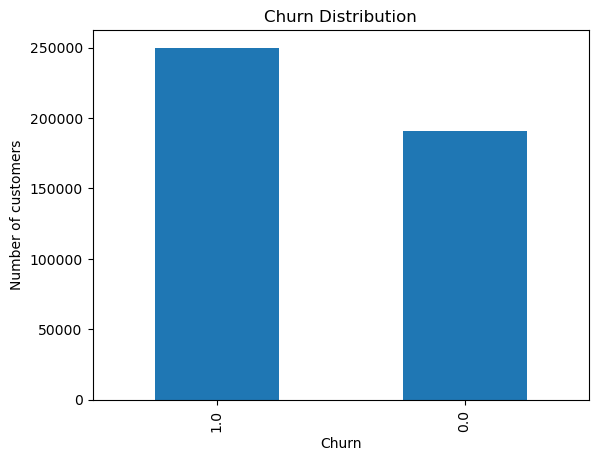

In [121]:
train_df["Churn"].value_counts().plot(kind = "bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")

plt.show()

In [122]:
train_df[num].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,440832.0,39.373153,12.442369,18.0,29.0,39.0,48.0,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.0,32.0,46.0,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.0,16.0,23.0,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.0,3.0,6.0,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.0,12.0,19.0,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.0,661.0,830.0,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.0,14.0,22.0,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.0,1.0,1.0,1.0


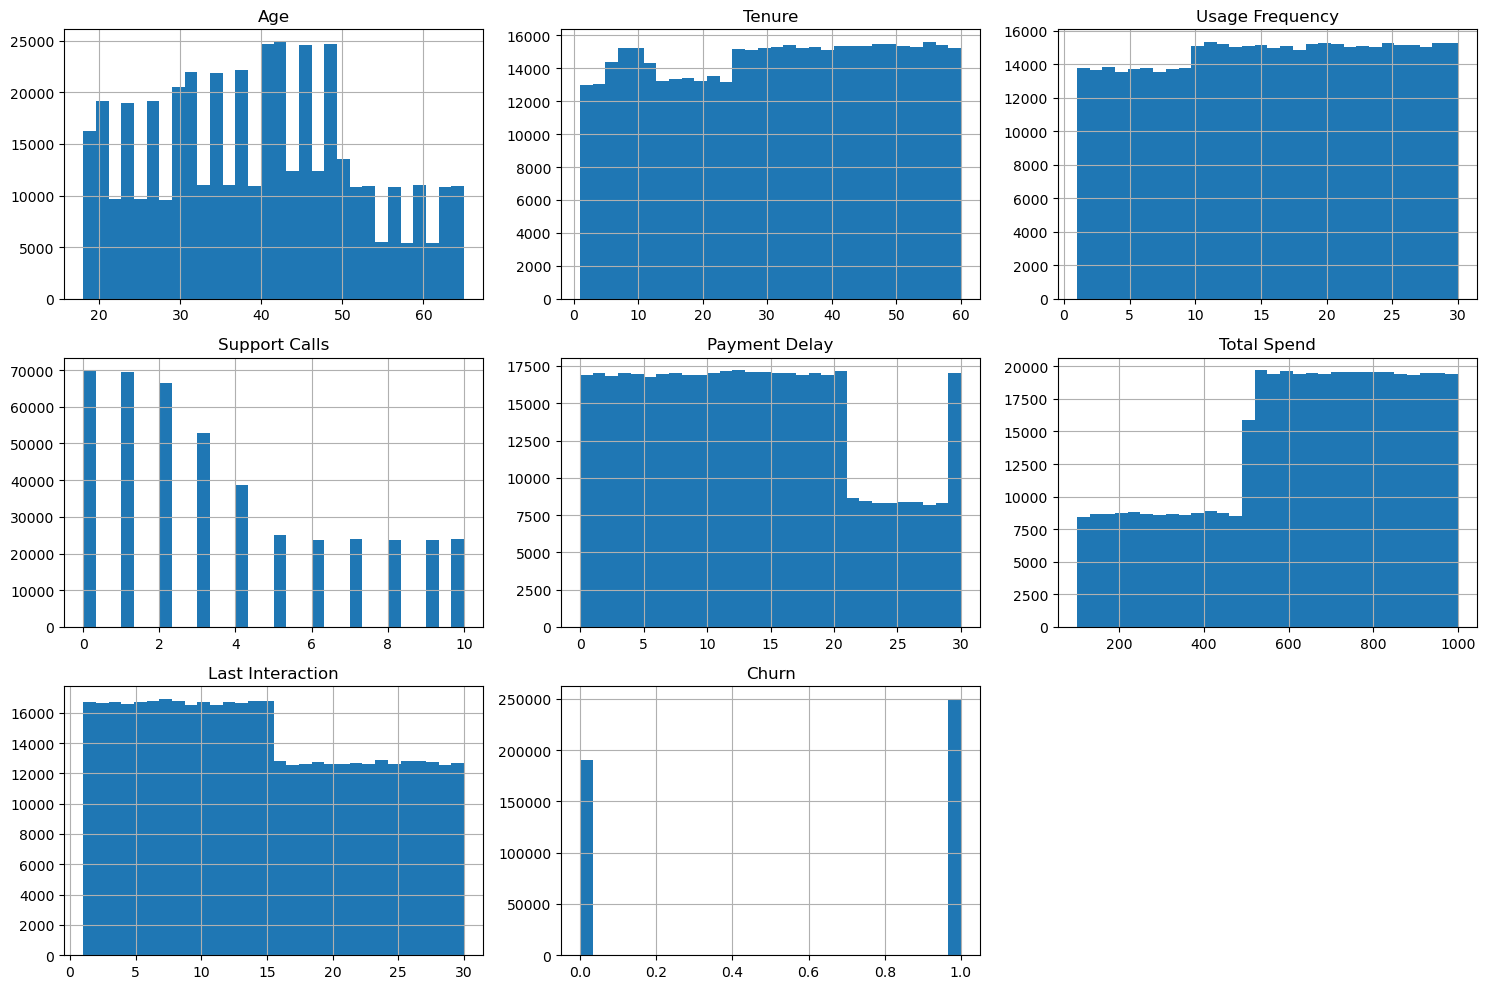

In [123]:
train_df[num].hist(figsize=(15, 10), bins=30)

plt.tight_layout()
plt.show()

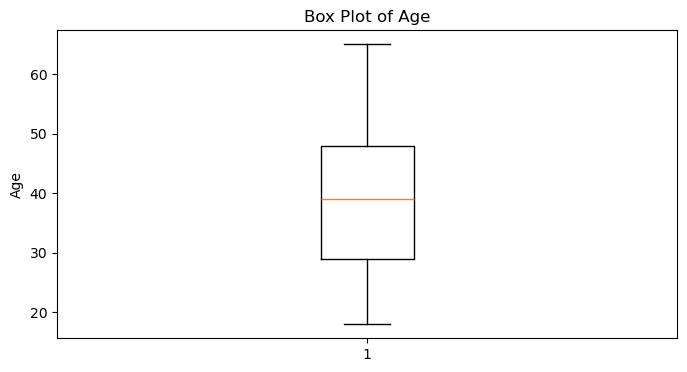

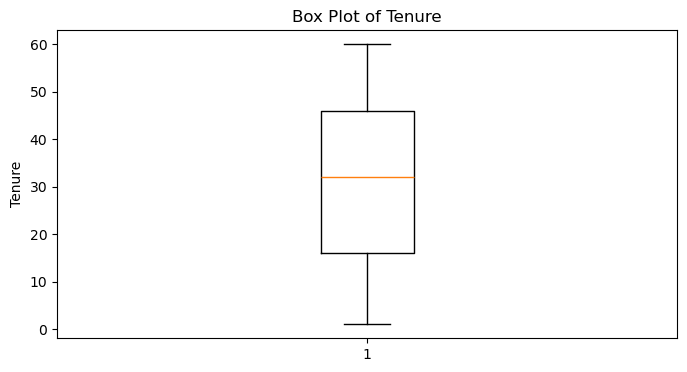

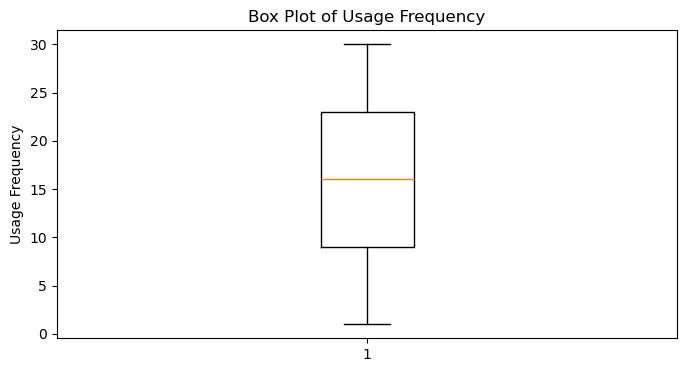

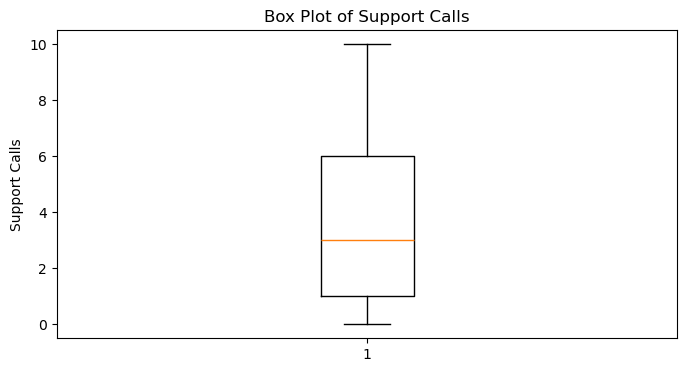

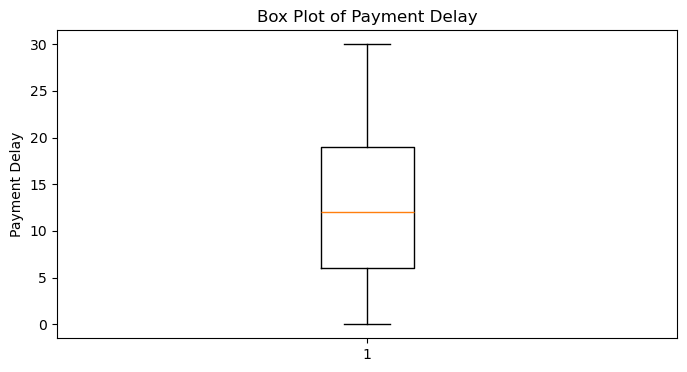

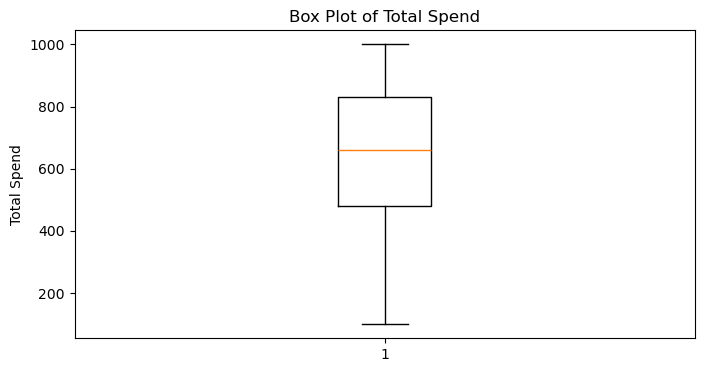

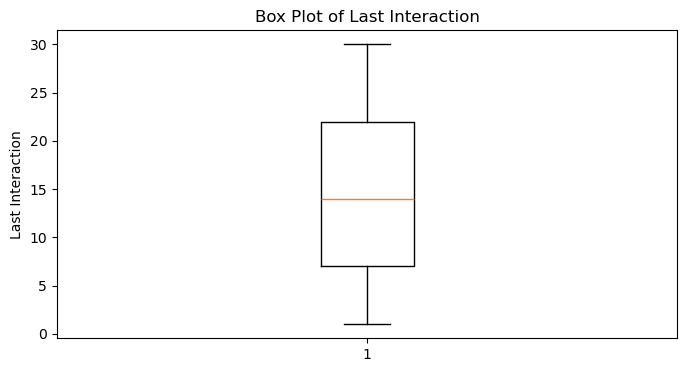

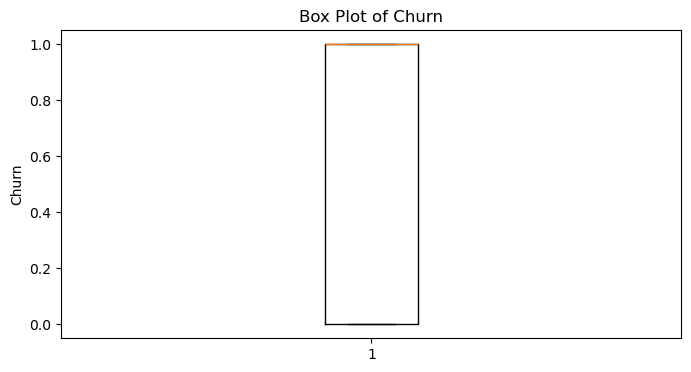

In [124]:
for col in num:
    plt.figure(figsize=(8, 4))
    plt.boxplot(train_df[col].dropna())
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

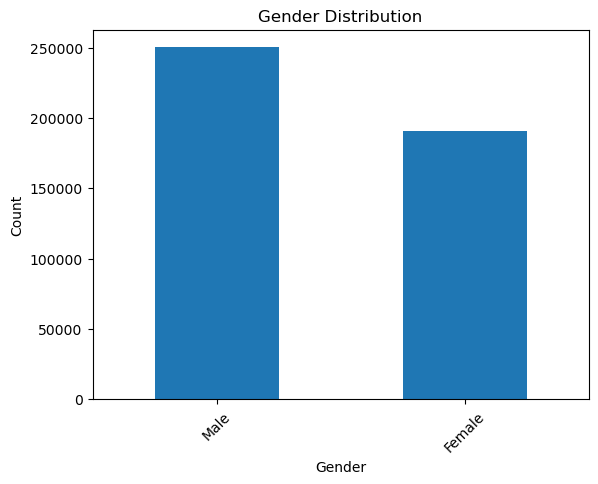

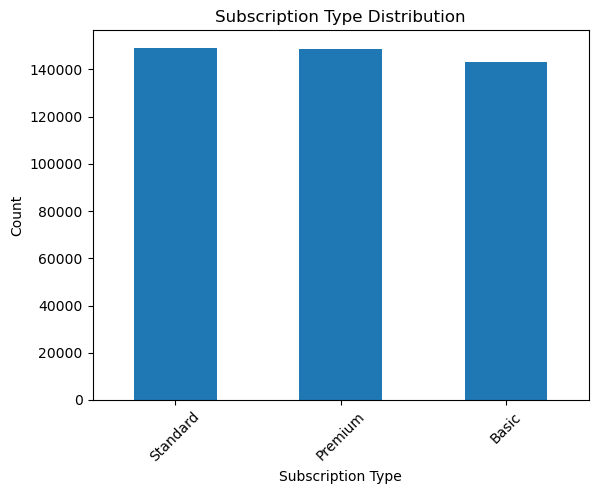

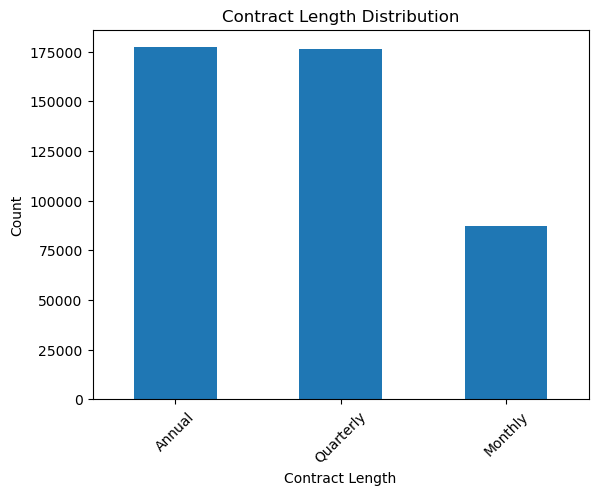

In [125]:
for col in cat:
    train_df[col].value_counts().plot(kind="bar")

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [126]:
train_df.groupby("Churn")[num].mean().T

Churn,0.0,1.0
Age,36.262973,41.747263
Tenure,32.281754,30.473598
Usage Frequency,16.260552,15.461658
Support Calls,1.586418,5.144861
Payment Delay,10.015500,15.217729
Total Spend,749.953111,541.285528
Last Interaction,13.008804,15.604546
Churn,0.000000,1.000000


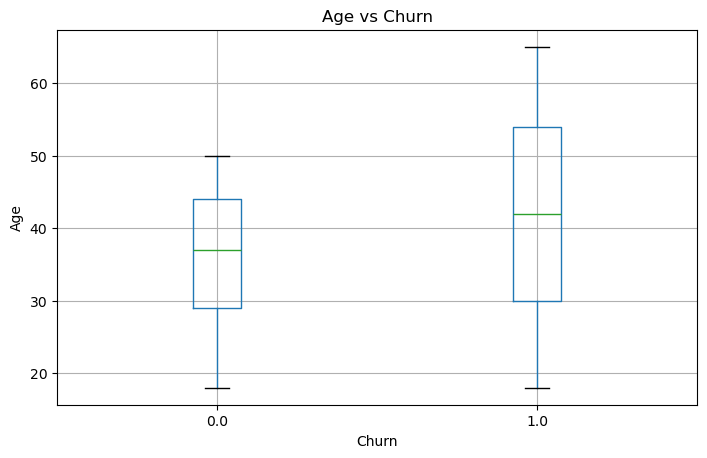

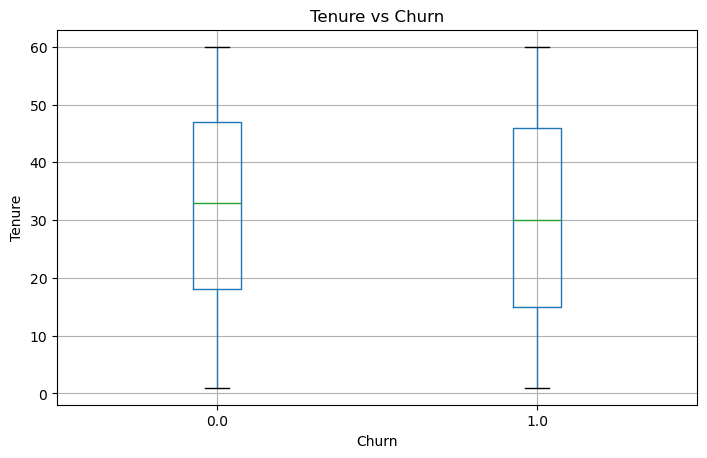

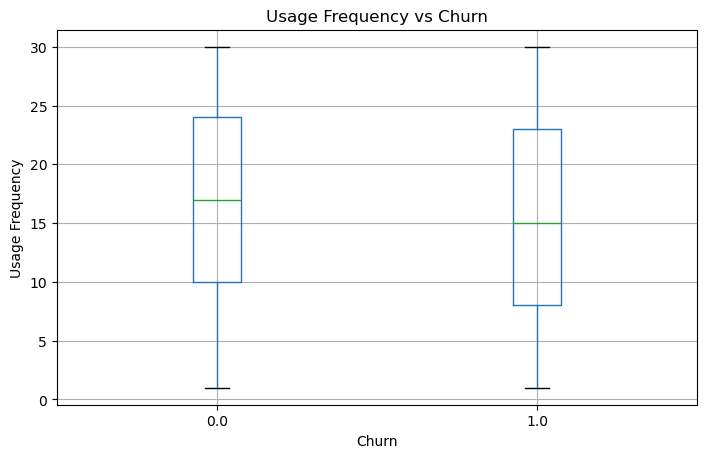

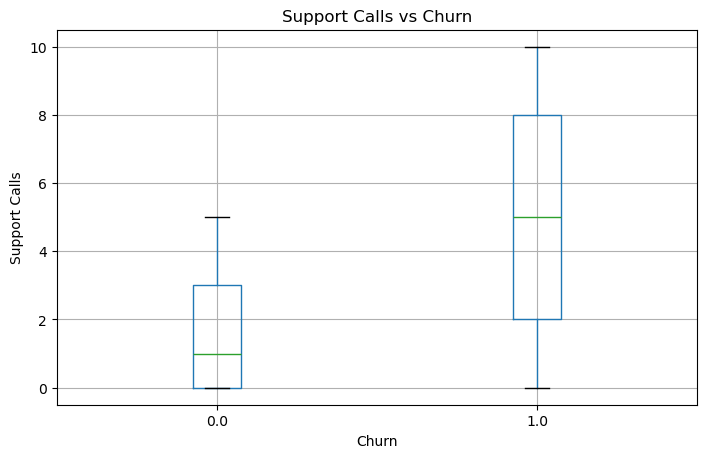

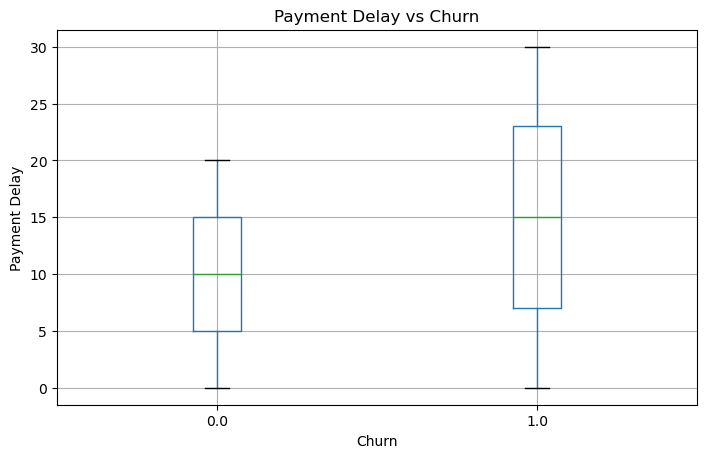

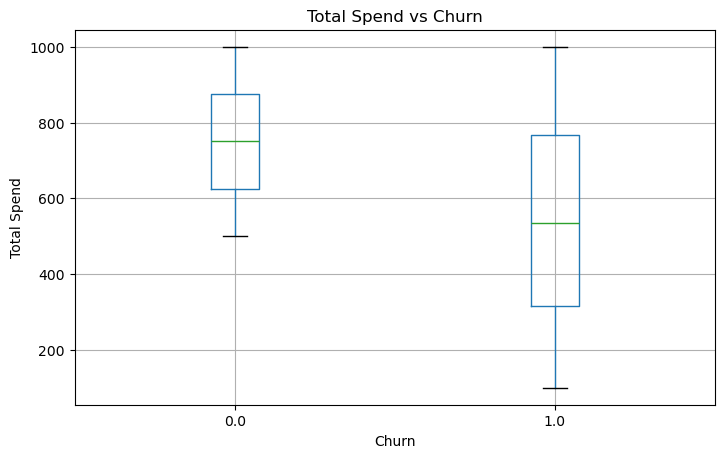

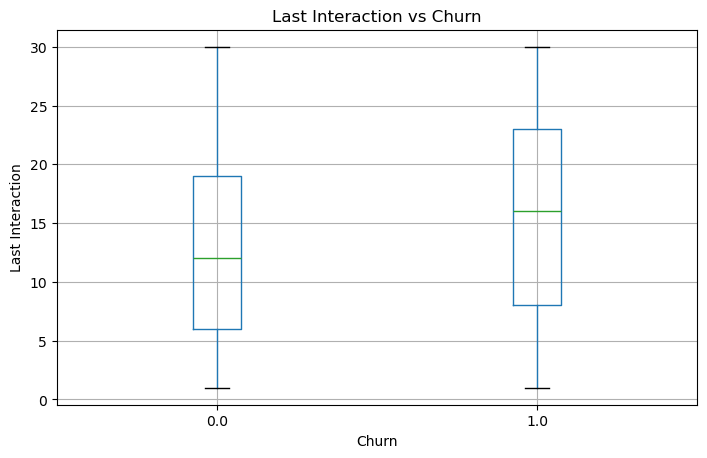

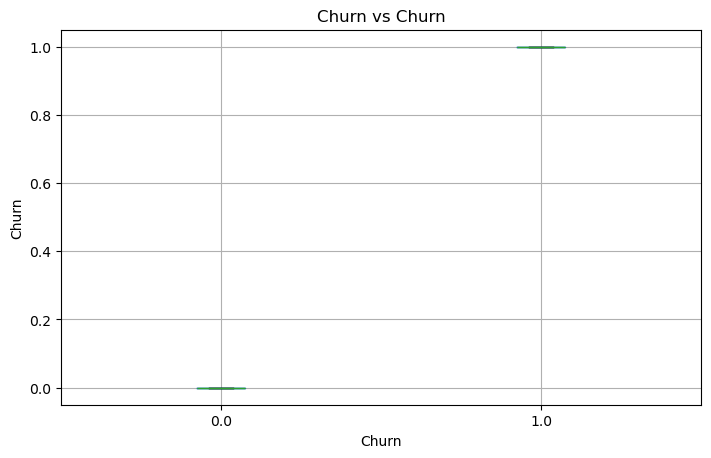

In [127]:
for col in num:
    train_df.boxplot(column=col, by="Churn", figsize=(8, 5))

    plt.title(f"{col} vs Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

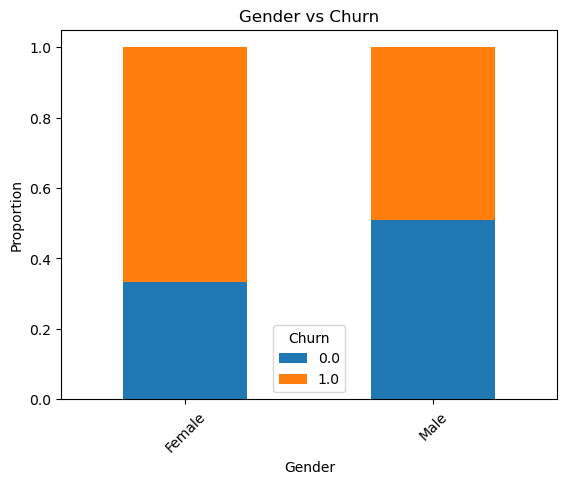

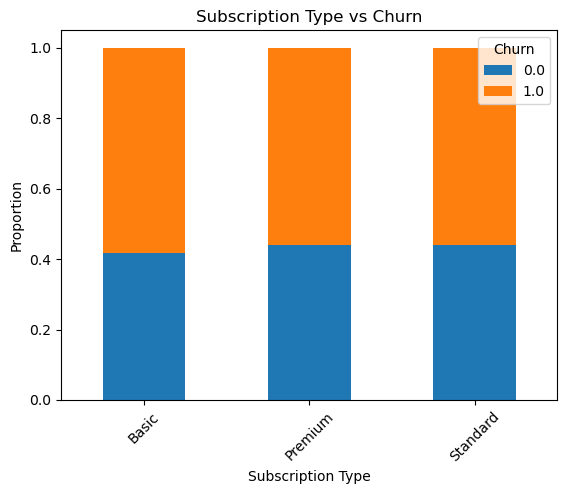

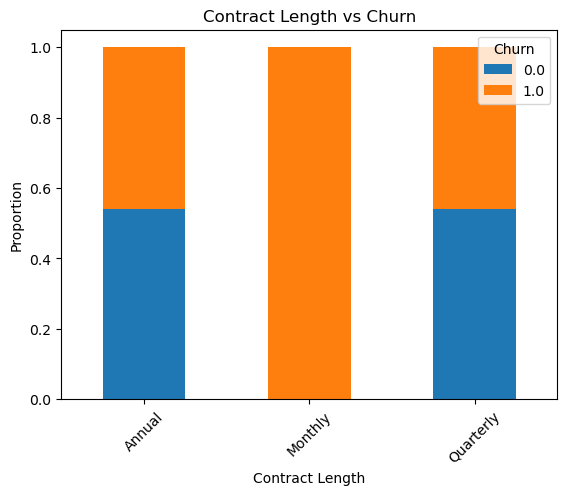

In [128]:
for col in cat:
    pd.crosstab(
        train_df[col],
        train_df["Churn"],
        normalize="index"
    ).plot(kind="bar", stacked=True)

    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="Churn")
    plt.xticks(rotation=45)
    plt.show()

In [129]:
corr = train_df[num].corr()
corr

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


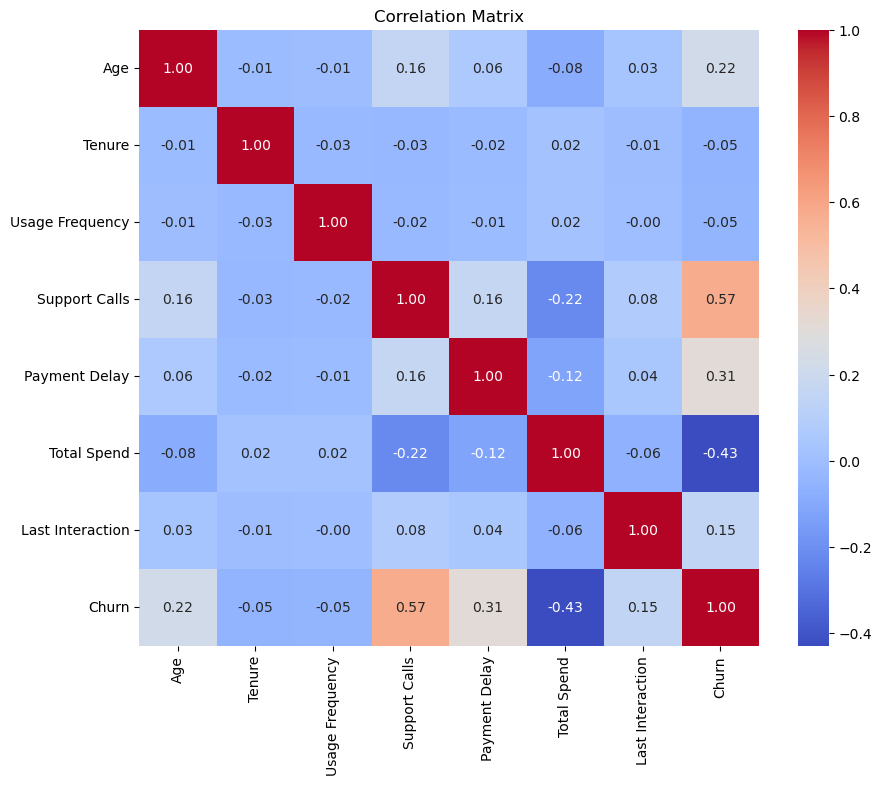

In [130]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [131]:
train_df[num].skew().sort_values()

Total Spend        -0.457174
Churn              -0.270881
Tenure             -0.061402
Usage Frequency    -0.043473
Age                 0.162016
Last Interaction    0.176774
Payment Delay       0.267407
Support Calls       0.666809
dtype: float64

In [132]:
for col in num:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Age: 0 outliers
Tenure: 0 outliers
Usage Frequency: 0 outliers
Support Calls: 0 outliers
Payment Delay: 0 outliers
Total Spend: 0 outliers
Last Interaction: 0 outliers
Churn: 0 outliers


# CATEGORICAL ENCODING 

In [133]:
X = train_df.drop(columns=["Churn", "CustomerID"])
y = train_df["Churn"]

In [134]:
X_test = test_df.drop(columns=["CustomerID"])

In [135]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat
        )
    ],
    remainder="passthrough"
)

In [136]:
X_encoded = preprocessor.fit_transform(X)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded X shape:", X_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Encoded X shape: (440832, 15)
Encoded X_test shape: (64374, 15)


# TRAIN / VALIDATION SPLIT + FEATURE SCALING 

In [137]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [138]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (352665, 10)
X_val: (88167, 10)
y_train: (352665,)
y_val: (88167,)


In [139]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

Training target distribution:
Churn
1.0    56.71076
0.0    43.28924
Name: proportion, dtype: float64

Validation target distribution:
Churn
1.0    56.710561
0.0    43.289439
Name: proportion, dtype: float64


In [140]:
scaler = StandardScaler()

In [143]:
num = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

In [144]:
X_train[num] = scaler.fit_transform(X_train[num])
X_val[num] = scaler.transform(X_val[num])

In [146]:
X_test[num] = scaler.transform(X_test[num])

In [ ]:
print(X_train[num].mean())

Age                 8.784445e-17
Tenure             -8.220306e-17
Usage Frequency     9.284111e-17
Support Calls      -9.670949e-19
Payment Delay       7.108147e-17
Total Spend         1.869717e-16
Last Interaction    6.608482e-18
dtype: float64


In [150]:
print(X_train[num].std())

Age                 1.000001
Tenure              1.000001
Usage Frequency     1.000001
Support Calls       1.000001
Payment Delay       1.000001
Total Spend         1.000001
Last Interaction    1.000001
dtype: float64


In [152]:
print(X_val[num].describe().T)

                    count      mean       std  ...       50%       75%       max
Age               88167.0 -0.003468  0.998790  ... -0.030677  0.692484  2.058454
Tenure            88167.0  0.005199  0.998876  ...  0.044127  0.855271  1.666415
Usage Frequency   88167.0 -0.009208  1.000401  ...  0.020581  0.835909  1.651238
Support Calls     88167.0 -0.001959  0.997289  ... -0.197156  0.779444  2.081578
Payment Delay     88167.0 -0.000391  0.997920  ... -0.116972  0.730332  2.061810
Total Spend       88167.0 -0.005667  1.001313  ...  0.114858  0.819729  1.529086
Last Interaction  88167.0  0.001692  0.999111  ... -0.055591  0.874887  1.805364

[7 rows x 8 columns]


# MODEL BUILDING